# Quick start demo (Visium ONT)

This notebook showcases the SPLISOSM spatial isoform analysis workflow on a [SiT (Visium-ONT) mouse olfactory bulb (MOB) dataset](https://academic.oup.com/nar/article/51/8/e47/7079641), which includes the following steps:
1. Run spatial variability (SV) tests to find genes with variable expression (SVE) or isoform usage (SVP).
2. Run differential isoform usage (DU) tests against spatial regions to find region markers.
3. Run differential isoform usage (DU) tests against RNA binding proteins (RBPs) to find potential regulators. 

The preprocessed MOB dataset is available for download from [Dropbox (~100 MB)](https://www.dropbox.com/scl/fo/dmuobtbof54jl4ht9zbjo/ALVIIEp-Ua5yYUPO8QxlIZ8?rlkey=q9o3jisd25ef5hwfqnsqdbf3i&st=vxhgokzw&dl=0). For preprocessing details, see [related scripts from the SPLISOSM paper](https://github.com/JiayuSuPKU/SPLISOSM_paper/tree/main/scripts/sit_data_analysis).

- `mob_ont_filtered_1107.h5ad`: AnnData object of isoform counts with spot metadata.
- `mob_visium_rbp_1107.h5ad`: AnnData object of RBP gene counts with spot metadata.

Estimated runtime: ~10 min.



## Imports

In [1]:
from pathlib import Path

import warnings
from sklearn.exceptions import ConvergenceWarning
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from splisosm import SplisosmNP, SplisosmGLMM
from splisosm.utils import run_hsic_gc, add_ratio_layer

In [2]:
# Update this path to your local data folder
DATA_DIR = Path("path/to/data/")
ont_path = DATA_DIR / "mob_ont_filtered_1107.h5ad"
rbp_path = DATA_DIR / "mob_visium_rbp_1107.h5ad"


In [3]:
# Local path
DATA_DIR = Path("/Users/jysumac/Projects/SPLISOSM_paper/results/sit_nar_23/anndata")
ont_path = DATA_DIR / "mob_ont_filtered_1107.h5ad"
rbp_path = DATA_DIR / "mob_visium_rbp_1107.h5ad"

## Load isoform-level `AnnData`

This MOB dataset contains only 918 spots and 1871 genes. Raw UMI counts, log-normalized counts, and isoform usage ratios are precomputed and stored as separate layers.

In [4]:
adata_ont = sc.read(ont_path)

# # log normalize
# sc.pp.normalize_total(adata_ont, target_sum=1e4)
# sc.pp.log1p(adata_ont)
# adata_ont.layers['log1p'] = adata_ont.X.copy()

# # compute observed isoform ratios
# from splisosm.utils import extract_counts_n_ratios
# _, _, _, ratio_obs = extract_counts_n_ratios(
#     adata_ont, layer = 'counts', group_iso_by = 'gene_symbol'
# )
# adata_ont.layers['ratios_obs'] = ratio_obs.copy() # dense matrix of shape (n_spots, n_isos)

print(f"== Number of spots: {adata_ont.n_obs}")
print(f"== Number of genes: {adata_ont.var['gene_symbol'].nunique()}")
print(f"== Number of isoforms: {adata_ont.shape[1]}")

adata_ont

== Number of spots: 918
== Number of genes: 1871
== Number of isoforms: 4529


AnnData object with n_obs × n_vars = 918 × 4529
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'AtoI_total', 'AtoI_ratio', 'AtoI_detected', 'in_tissue', 'array_row', 'array_col'
    var: 'features', 'n_cells', 'gene_symbol', 'transcript_id', 'transcript_name'
    uns: 'log1p', 'spatial'
    obsm: 'spatial'
    layers: 'counts', 'log1p', 'ratios_obs'

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/638070984.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_ont, color = [None, 'region'], title=['H&E', 'Region'], img_key = 'lowres')


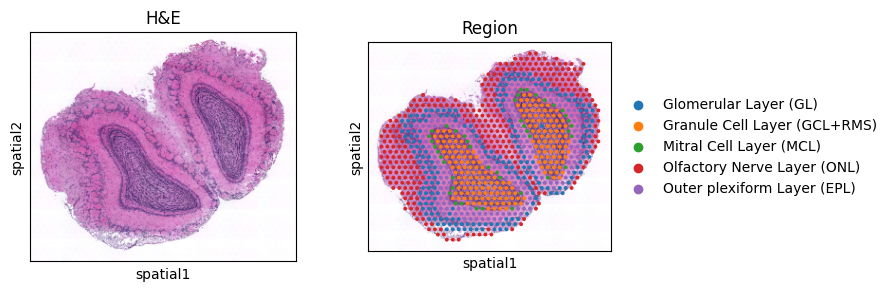

In [5]:
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.spatial(adata_ont, color = [None, 'region'], title=['H&E', 'Region'], img_key = 'lowres')

## Spatial variability (SV) tests
We first set up the `SplisosmNP` model for SV testing using the AnnData as inputs.

In [6]:
%%time
model_sv = SplisosmNP()
model_sv.setup_data(
    adata=adata_ont,
    spatial_key="spatial",
    layer="counts",
    group_iso_by="gene_symbol",
    gene_names="gene_symbol",
    # optionally, remove minor isoforms and single-isoform genes
    min_counts=10,
    min_bin_pct=0.01,
    filter_single_iso_genes=True,
)
model_sv

CPU times: user 564 ms, sys: 21.1 ms, total: 585 ms
Wall time: 261 ms


=== SplisosmNP
- Number of genes: 1871
- Number of spots: 918
- Number of covariates: 0
- Average isoforms per gene: 2.4
=== Model configurations
- Spatial kernel source: spatial_key='spatial'
- k_neighbors: 4, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [7]:
# Top 5 genes with the most effective isoforms
model_sv.extract_feature_summary(level="gene").sort_values(
    "perplexity", ascending=False
).head(5)

Genes:   0%|          | 0/1871 [00:00<?, ?it/s]

Genes:  19%|█▉        | 354/1871 [00:00<00:00, 3530.64it/s]

Genes:  41%|████      | 767/1871 [00:00<00:00, 3878.99it/s]

Genes:  64%|██████▍   | 1202/1871 [00:00<00:00, 4092.79it/s]

Genes:  86%|████████▌ | 1612/1871 [00:00<00:00, 3774.18it/s]

Genes: 100%|██████████| 1871/1871 [00:00<00:00, 3778.77it/s]

,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
gene,,,,,,
Pigx,6,5.524084,0.226580,0.284314,0.589296,0.275862
0610010K14Rik,6,5.430532,0.264706,0.338780,0.639682,0.260450
Rpl41,6,5.096268,0.314815,0.391068,0.642204,0.367688
Mff,7,5.048239,0.285403,0.386710,0.730385,0.433803
Hmga1,6,4.987885,0.159041,0.201525,0.515255,0.281081


### Find spatially variably expressed (SVE) genes

Here we will aggregate isoform counts to gene level and then run the HSIC-GC test to see if the total expression of a gene is spatially variable. 
Because the dataset is small, exact spatial-kernel cumulants are used by default. For large implicit CAR kernels, set `null_configs = {'n_probes': int}` in `test_spatial_variability` to tune the Hutchinson trace budget.


In [8]:
%%time
model_sv.test_spatial_variability(method="hsic-gc", null_method='liu')
sve_res = model_sv.get_formatted_test_results(test_type="sv").sort_values("pvalue")
sve_res.head(5)

SV [hsic-gc]:   0%|          | 0/1871 [00:00<?, ?it/s]

SV [hsic-gc]:  14%|█▍        | 270/1871 [00:00<00:00, 2604.15it/s]

SV [hsic-gc]:  28%|██▊       | 531/1871 [00:00<00:00, 2450.15it/s]

SV [hsic-gc]:  42%|████▏     | 777/1871 [00:00<00:00, 2434.73it/s]

SV [hsic-gc]:  55%|█████▍    | 1021/1871 [00:00<00:00, 2322.96it/s]

...

SV [hsic-gc]:  80%|███████▉  | 1492/1871 [00:00<00:00, 2288.77it/s]

SV [hsic-gc]:  92%|█████████▏| 1730/1871 [00:00<00:00, 2292.95it/s]

SV [hsic-gc]: 100%|██████████| 1871/1871 [00:00<00:00, 2332.94it/s]

CPU times: user 542 ms, sys: 1.78 s, total: 2.32 s
Wall time: 876 ms


,gene,statistic,pvalue,pvalue_adj
242,Apoe,0.282076,3.754603e-58,7.024863e-55
979,Tmsb4x,0.584759,1.489961e-47,1.393859e-44
753,Rps5,0.155722,1.683513e-39,1.049951e-36
682,Apod,0.240496,5.436647e-39,2.542992e-36
1177,Fth1,1.767817,6.668358e-38,2.495300e-35


Or alternatively, through a convenient standalone wrapper function `splisosm.utils.run_hsic_gc()`:

In [9]:
%%time
# Aggregate isoform counts to gene level
iso_to_gene = pd.get_dummies(adata_ont.var["gene_symbol"])
gene_counts = adata_ont.layers["counts"].copy() @ iso_to_gene.values # (918, 1871)

# Extract spatial coordinates
coords = adata_ont.obsm["spatial"] # (918, 2)

# Run the HSIC-GC wrapper function splisosm.utils.run_hsic_gc
sve_res_wrapper = run_hsic_gc(
    counts_gene=gene_counts, 
    coordinates=coords,
    null_method='liu',
    # SplisosmNP default configurations for spatial kernel:
    k_neighbors=4, 
    rho=0.99,
    standardize_cov=True,
)
sve_res_wrapper = pd.DataFrame(
    {'gene': iso_to_gene.columns.values} | sve_res_wrapper
).sort_values("pvalue")
sve_res_wrapper.head(5)


Genes:   0%|          | 0/1871 [00:00<?, ?it/s]

Genes:  74%|███████▍  | 1386/1871 [00:00<00:00, 13855.55it/s]

Genes: 100%|██████████| 1871/1871 [00:00<00:00, 14042.63it/s]

CPU times: user 398 ms, sys: 18.6 ms, total: 417 ms
Wall time: 373 ms


,gene,statistic,pvalue,method,null_method,n_spots,pvalue_adj
1679,Tmsb4x,0.584759,0.000000e+00,hsic-gc,liu,918,0.000000e+00
119,Apoe,0.282076,0.000000e+00,hsic-gc,liu,918,0.000000e+00
1387,Rps5,0.155722,1.683513e-39,hsic-gc,liu,918,1.049951e-36
118,Apod,0.240496,5.436647e-39,hsic-gc,liu,918,2.542992e-36
581,Fth1,1.767817,6.668358e-38,hsic-gc,liu,918,2.495300e-35


### Find spatially variably processed (SVP) genes

Here we will run the HSIC-IR test to see if the isoform usage of a gene is spatially variable, independently of its overall expression level.

In [10]:
%%time
model_sv.test_spatial_variability(
    method="hsic-ir", 
    null_method='liu',
    ratio_transformation="none", 
    nan_filling="mean"
)
svp_res = model_sv.get_formatted_test_results(
    test_type="sv", with_gene_summary=True
).sort_values("pvalue")
svp_res.head(5)

SV [hsic-ir]:   0%|          | 0/1871 [00:00<?, ?it/s]

SV [hsic-ir]:  10%|▉         | 180/1871 [00:00<00:00, 1768.99it/s]

SV [hsic-ir]:  19%|█▉        | 357/1871 [00:00<00:00, 1745.97it/s]

SV [hsic-ir]:  28%|██▊       | 532/1871 [00:00<00:00, 1682.46it/s]

SV [hsic-ir]:  37%|███▋      | 701/1871 [00:00<00:00, 1681.01it/s]

...

SV [hsic-ir]:  83%|████████▎ | 1545/1871 [00:00<00:00, 1624.00it/s]

SV [hsic-ir]:  91%|█████████▏| 1710/1871 [00:01<00:00, 1606.15it/s]

SV [hsic-ir]: 100%|██████████| 1871/1871 [00:01<00:00, 1648.29it/s]

CPU times: user 704 ms, sys: 3.11 s, total: 3.82 s
Wall time: 1.15 s


,gene,statistic,pvalue,pvalue_adj,n_isos,perplexity,pct_bin_on,count_avg,count_std,major_ratio_avg
1023,Myl6,0.000692,3.148206e-15,5.890294e-12,4,2.568840,0.807190,2.335512,2.222548,0.476213
304,Rps24,0.000482,2.446118e-12,2.288343e-09,4,2.093565,0.844227,2.331155,1.913525,0.731776
1461,Rpl5,0.000526,9.723740e-12,6.064372e-09,3,2.143138,0.527233,0.973856,1.288195,0.510067
1539,Plp1,0.000312,8.414001e-09,3.935649e-06,2,1.998197,0.331155,0.744009,2.231397,0.521230
216,Clta,0.000430,2.332957e-05,8.729926e-03,5,2.951403,0.724401,1.820261,1.999276,0.606224


### Compare SVE and SVP results

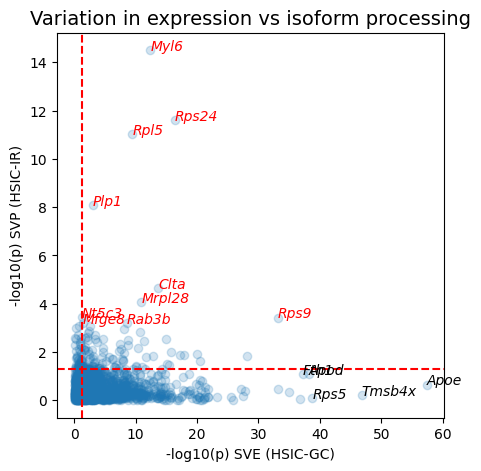

In [11]:
def _neg_log10(p, floor=1e-300):
    return -np.log10(np.clip(p, floor, 1.0))

sv_genes = sve_res.merge(svp_res, on="gene", suffixes=("_sve", "_svp"))

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    _neg_log10(sv_genes["pvalue_sve"]),
    _neg_log10(sv_genes["pvalue_svp"]),
    alpha=0.2
)
# add pvalue = 0.05 lines
ax.axhline(_neg_log10(0.05), color="red", linestyle="--")
ax.axvline(_neg_log10(0.05), color="red", linestyle="--")

# annotate top 10 genes by SVP p-value
top_10_svp = sv_genes.nsmallest(10, "pvalue_svp")
for i, (idx, row) in enumerate(top_10_svp.iterrows()):
    ax.annotate(row["gene"], xy=(_neg_log10(row["pvalue_sve"]), _neg_log10(row["pvalue_svp"])), 
                style='italic', fontsize=10, color="red")

# annotate top 5 genes by SVE p-value
top_5_sve = sv_genes.nsmallest(5, "pvalue_sve")
for i, (idx, row) in enumerate(top_5_sve.iterrows()):
    if row["gene"] not in top_10_svp["gene"].values:
        # only annotate non-SVP genes
        ax.annotate(
            row["gene"], xy=(_neg_log10(row["pvalue_sve"]), _neg_log10(row["pvalue_svp"])), 
            style='italic', fontsize=10, color="black"
        )
    
ax.set_xlabel("-log10(p) SVE (HSIC-GC)", fontsize=10)
ax.set_ylabel("-log10(p) SVP (HSIC-IR)", fontsize=10)
ax.set_title("Variation in expression vs isoform processing", fontsize=14)
plt.show()


We can take a look at genes with spatially variable isoform usage as well as genes with only variable expression, to see how they differ.

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/3160921472.py:11: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


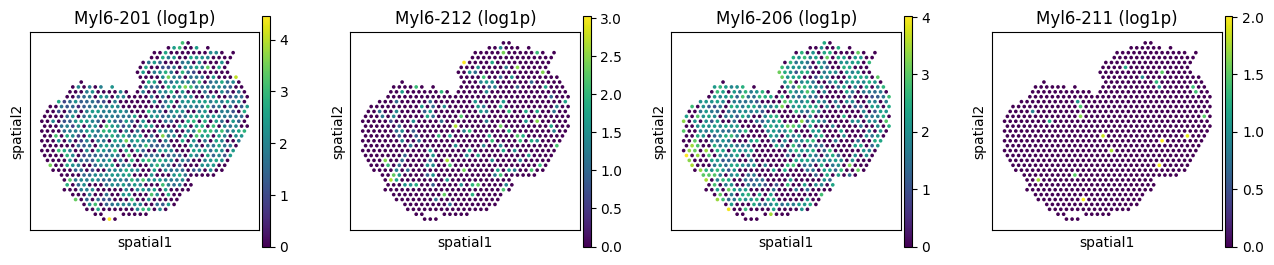

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/3160921472.py:15: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


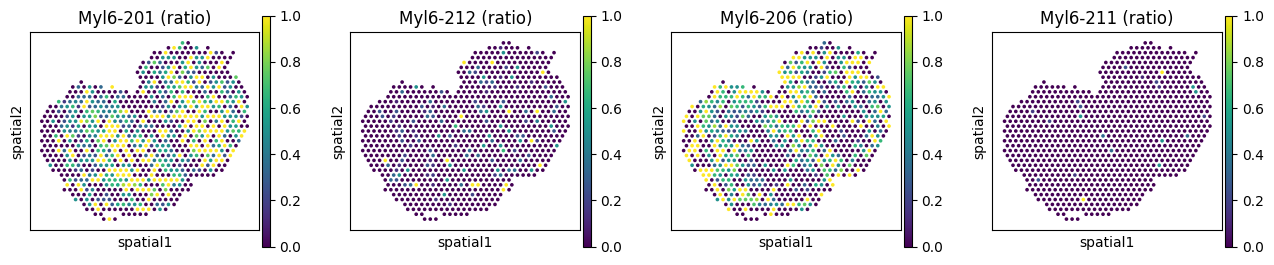

In [12]:
# Compute isoform ratios and store in a new layer "ratios_obs"
add_ratio_layer(adata_ont, group_iso_by="gene_symbol", layer="counts", ratio_layer_key="ratios_obs")

# Spatially variably processed: Myl6
_gene = "Myl6"
_iso_to_plot = adata_ont.var.index[adata_ont.var['gene_symbol'] == _gene]
_name_to_plot = adata_ont.var.loc[adata_ont.var['gene_symbol'] == _gene, 'transcript_name']
_titles_log1p = [f"{name} (log1p)" for name in _name_to_plot]
_titles_ratio = [f"{name} (ratio)" for name in _name_to_plot]
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.spatial(
        adata_ont, color=_iso_to_plot, title=_titles_log1p,
        img_key=None, layer='log1p', ncols = len(_iso_to_plot)
    )
    sc.pl.spatial(
        adata_ont, color=_iso_to_plot, title=_titles_ratio,
        img_key=None, layer='ratios_obs', ncols = len(_iso_to_plot)
    )

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/1513142415.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


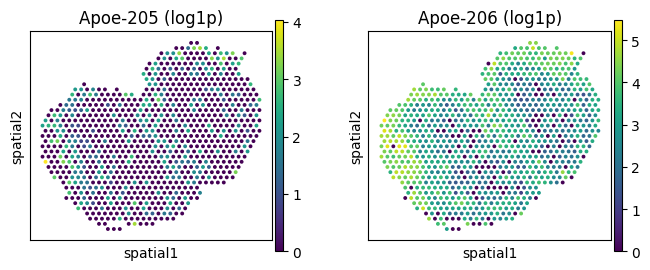

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/1513142415.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


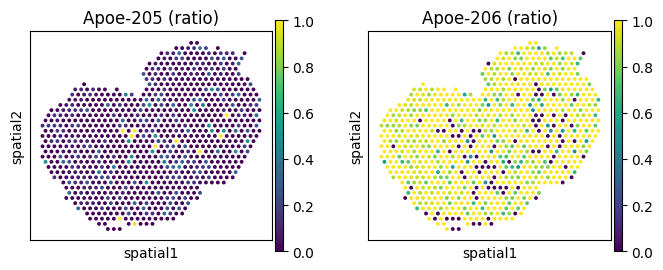

In [13]:
# Spatially variably expressed but not processed: Apoe
_gene = "Apoe"
_iso_to_plot = adata_ont.var.index[adata_ont.var['gene_symbol'] == _gene]
_name_to_plot = adata_ont.var.loc[adata_ont.var['gene_symbol'] == _gene, 'transcript_name']
_titles_log1p = [f"{name} (log1p)" for name in _name_to_plot]
_titles_ratio = [f"{name} (ratio)" for name in _name_to_plot]
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.spatial(
        adata_ont, color=_iso_to_plot, title=_titles_log1p,
        img_key=None, layer='log1p', ncols = len(_iso_to_plot)
    )
    sc.pl.spatial(
        adata_ont, color=_iso_to_plot, title=_titles_ratio,
        img_key=None, layer='ratios_obs', ncols = len(_iso_to_plot)
    )

## Differential isoform usage (DU) tests

The covariates for DU tests can be any spot-level metadata, such as spatial regions or RBP expression levels.


### Find isoform switching events between spatial regions

We will first use the spatial region annotation available from the original SiT paper.

In [14]:
%%time
# Subset to the significant SVP genes
svp_gene_list = svp_res.query("pvalue < 0.01")["gene"].tolist()
adata_svp = adata_ont[:, adata_ont.var["gene_symbol"].isin(svp_gene_list)].copy()

# Create a model with design matrix based on spatial regions
model_region = SplisosmNP()
model_region.setup_data(
    adata=adata_svp,
    # will one-hot encode the region column in adata.obs
    design_mtx='region',
    spatial_key="spatial",
    layer="counts",
    group_iso_by="gene_symbol",
    gene_names="gene_symbol",
    min_counts=10,
    min_bin_pct=0.01,
    skip_spatial_kernel=True, # DU test does not require initializing spatial kernel
)
model_region

CPU times: user 12.4 ms, sys: 3.75 ms, total: 16.2 ms
Wall time: 18.2 ms


=== SplisosmNP
- Number of genes: 51
- Number of spots: 918
- Number of covariates: 5
- Average isoforms per gene: 2.6
=== Model configurations
- Spatial kernel source: identity (skip_spatial_kernel=True)
- k_neighbors: N/A, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [15]:
%%time
# Conditional DU test using sklearn's GaussianProgressRegressor (default)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning, message=".*is close to the specified.*")
    model_region.test_differential_usage(method="hsic-gp", gpr_backend="sklearn")

du_res = model_region.get_formatted_test_results(test_type="du").sort_values("pvalue")
du_res.head(5)

Covariates:   0%|          | 0/5 [00:00<?, ?it/s]

Covariates:  20%|██        | 1/5 [00:00<00:00,  4.54it/s]

Covariates:  40%|████      | 2/5 [00:00<00:00,  4.55it/s]

Covariates:  60%|██████    | 3/5 [00:00<00:00,  3.94it/s]

Covariates:  80%|████████  | 4/5 [00:00<00:00,  4.06it/s]

...

DU [hsic-gp]:   0%|          | 0/51 [00:00<?, ?it/s]

DU [hsic-gp]:  78%|███████▊  | 40/51 [00:00<00:00, 353.09it/s]

DU [hsic-gp]: 100%|██████████| 51/51 [00:00<00:00, 354.06it/s]

CPU times: user 1.35 s, sys: 801 ms, total: 2.15 s
Wall time: 1.46 s


,gene,covariate,statistic,pvalue,pvalue_adj
233,Plp1,region_Olfactory Nerve Layer (ONL),0.000973,0.000001,0.000038
130,Nnat,region_Glomerular Layer (GL),0.003000,0.000001,0.000042
133,Nnat,region_Olfactory Nerve Layer (ONL),0.001121,0.000002,0.000038
225,Ap3s1,region_Glomerular Layer (GL),0.002433,0.000002,0.000042
226,Ap3s1,region_Granule Cell Layer (GCL+RMS),0.000906,0.000002,0.000124


Let's plot the most significant switching events for each region.

In [16]:
du_res.groupby("covariate").apply(
    lambda df: df.nsmallest(1, "pvalue"),
    include_groups=False
)

,,gene,statistic,pvalue,pvalue_adj
covariate,,,,,
region_Glomerular Layer (GL),130,Nnat,0.003000,0.000001,0.000042
region_Granule Cell Layer (GCL+RMS),226,Ap3s1,0.000906,0.000002,0.000124
region_Mitral Cell Layer (MCL),227,Ap3s1,0.002586,0.000025,0.001298
region_Olfactory Nerve Layer (ONL),233,Plp1,0.000973,0.000001,0.000038
region_Outer plexiform Layer (EPL),94,Rps9,0.000807,0.009689,0.390307


/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/720942732.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


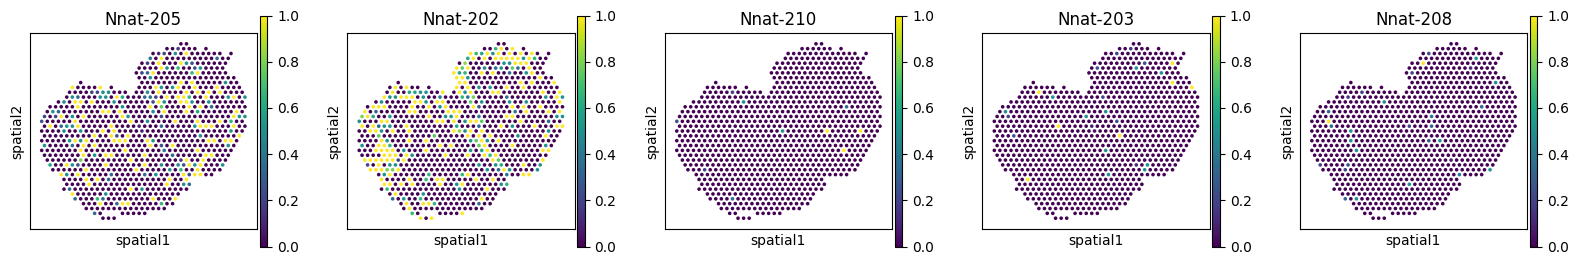

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/720942732.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


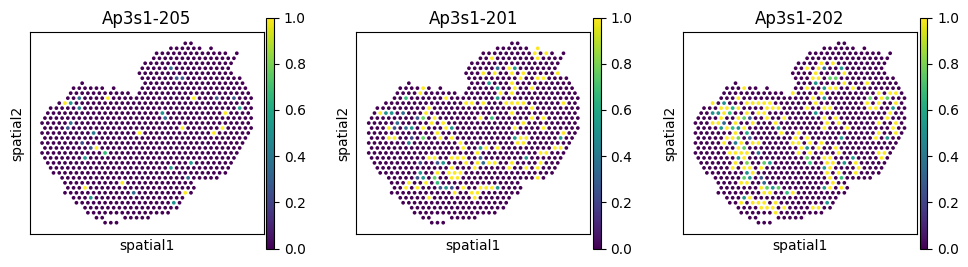

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/720942732.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


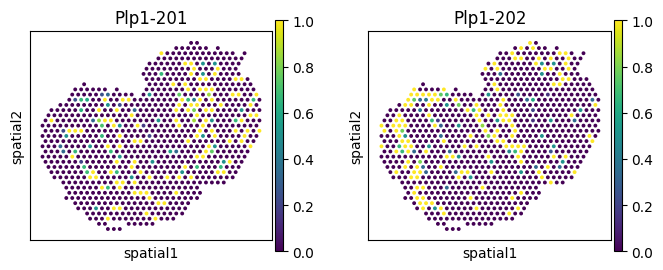

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/720942732.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


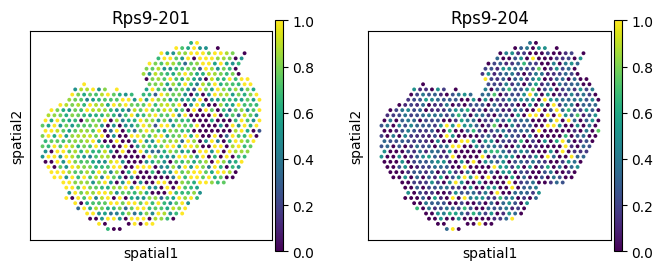

In [17]:
for _gene in ['Nnat', 'Ap3s1', 'Plp1', 'Rps9']:
    _iso_to_plot = adata_ont.var.index[adata_ont.var['gene_symbol'] == _gene]
    _name_to_plot = adata_ont.var.loc[adata_ont.var['gene_symbol'] == _gene, 'transcript_name']
    with plt.rc_context({"figure.figsize": (3, 3)}):
        sc.pl.spatial(
            adata_ont, color=_iso_to_plot, title=_name_to_plot,
            img_key=None, layer='ratios_obs', ncols = len(_iso_to_plot)
        )

### Find potential RBP regulators of isoform switching events

Next, we load the short-read-based expression matrix of all RNA binding proteins (RBPs) in the same dataset. The list of RBPs is obtained from [EuRBPDB](http://eurbpdb.gzsys.org.cn/index.php), excluding ribosomal proteins and non-canonical RBPs.

In [18]:
adata_rbp = sc.read(rbp_path)
adata_rbp

# # log normalize is performed with all genes
# sc.pp.normalize_total(adata_sr, target_sum=1e4)
# sc.pp.log1p(adata_sr)
# adata_sr.layers['log1p'] = adata_sr.X.copy()
# data_rbp = adata_sr[:, adata_sr.var_names.isin(rbp_genes)].copy()

AnnData object with n_obs × n_vars = 918 × 1399
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'region', 'AtoI_total', 'AtoI_ratio', 'AtoI_detected', 'in_tissue', 'array_row', 'array_col'
    var: 'features', 'n_cells', 'is_rbp', 'pvalue_adj_hsic', 'pvalue_adj_sparkx', 'is_visium_sve'
    uns: 'log1p', 'spatial'
    obsm: 'spatial'
    layers: 'counts', 'log1p'

Let's first run SVE test (HSIC-GC) to find spatially variably expressed RBPs.

In [19]:
%%time
# Run the HSIC-GC wrapper function (anndata mode)
sve_rbp = run_hsic_gc(
    adata=adata_rbp,
    layer='counts',
    spatial_key='spatial',
    null_method='liu',
    k_neighbors=4, 
    rho=0.99,
    standardize_cov=True,
)
sve_rbp = pd.DataFrame(
    {'gene': adata_rbp.var_names} | sve_rbp
).sort_values("pvalue")

print(f"Number of SVE RBPs (FDR < 0.01): {(sve_rbp['pvalue_adj'] < 0.01).sum()} / {adata_rbp.shape[1]}")
sve_rbp.head(5)

Genes:   0%|          | 0/1399 [00:00<?, ?it/s]

Genes:   4%|▍         | 53/1399 [00:00<00:02, 526.78it/s]

Genes:   8%|▊         | 107/1399 [00:00<00:02, 529.79it/s]

Genes:  12%|█▏        | 161/1399 [00:00<00:02, 531.54it/s]

Genes:  15%|█▌        | 215/1399 [00:00<00:02, 531.26it/s]

...

Genes:  96%|█████████▌| 1344/1399 [00:02<00:00, 523.49it/s]

Genes: 100%|█████████▉| 1398/1399 [00:02<00:00, 526.03it/s]

Genes: 100%|██████████| 1399/1399 [00:02<00:00, 528.78it/s]

Number of SVE RBPs (FDR < 0.01): 455 / 1399
CPU times: user 2.84 s, sys: 20.6 ms, total: 2.86 s
Wall time: 2.75 s


,gene,statistic,pvalue,method,null_method,n_spots,pvalue_adj
1326,Ndufa2,0.244349,1.237828e-29,hsic-gc,liu,918,1.731721e-26
1185,Arf3,0.018160,1.160638e-27,hsic-gc,liu,918,8.118662e-25
876,Eef1a1,0.392478,2.804892e-27,hsic-gc,liu,918,1.308015e-24
911,Ewsr1,0.033771,7.898943e-25,hsic-gc,liu,918,2.762655e-22
300,Rab2a,0.058817,4.462313e-23,hsic-gc,liu,918,1.248555e-20


We can then run conditional HSIC (`method="hsic-gp"`) to find potential RBP regulators of the isoform switching events.

In [20]:
%%time
# Subset to the significant SVP genes
svp_gene_list = svp_res.query("pvalue < 0.01")["gene"].tolist()
adata_svp = adata_ont[:, adata_ont.var["gene_symbol"].isin(svp_gene_list)].copy()

# Subset to the significant SVE RBPs
sve_rbp_list = sve_rbp.query("pvalue_adj < 0.01")["gene"].tolist()
adata_rbp_sve = adata_rbp[
    adata_svp.obs_names, 
    adata_rbp.var_names.isin(sve_rbp_list)
]
design_mtx = adata_rbp_sve.layers['log1p'].copy()
covariate_names = adata_rbp_sve.var_names.tolist()

# Create a model with RBP expression as covariates
model_rbp = SplisosmNP()
model_rbp.setup_data(
    adata=adata_svp,
    design_mtx=design_mtx,
    covariate_names=covariate_names,
    spatial_key="spatial",
    layer="counts",
    group_iso_by="gene_symbol",
    gene_names="gene_symbol",
    min_counts=10,
    min_bin_pct=0.01,
    skip_spatial_kernel=True, # DU test does not require initializing spatial kernel
)
model_rbp


CPU times: user 15.3 ms, sys: 3.76 ms, total: 19.1 ms
Wall time: 18.5 ms


=== SplisosmNP
- Number of genes: 51
- Number of spots: 918
- Number of covariates: 455
- Average isoforms per gene: 2.6
=== Model configurations
- Spatial kernel source: identity (skip_spatial_kernel=True)
- k_neighbors: N/A, rho: 0.99
- Standardize spatial covariance: True
=== Test results
- Spatial variability: N/A
- Differential usage: N/A

In [21]:
%%time
# Conditional: spatially residualize both probe usage and RBP expression
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=ConvergenceWarning, message=".*is close to the specified.*")
    model_rbp.test_differential_usage(method="hsic-gp", gpr_backend='sklearn')
    du_rbp_sklearn = model_rbp.get_formatted_test_results(test_type="du").rename(columns={"pvalue": "pvalue_np"})

Covariates:   0%|          | 0/455 [00:00<?, ?it/s]

Covariates:   0%|          | 1/455 [00:00<01:16,  5.96it/s]

Covariates:   0%|          | 2/455 [00:00<01:49,  4.14it/s]

Covariates:   1%|          | 3/455 [00:00<02:12,  3.41it/s]

Covariates:   1%|          | 4/455 [00:01<01:59,  3.78it/s]

...

DU [hsic-gp]:  59%|█████▉    | 30/51 [00:06<00:04,  4.24it/s]

DU [hsic-gp]:  78%|███████▊  | 40/51 [00:09<00:02,  3.74it/s]

DU [hsic-gp]:  98%|█████████▊| 50/51 [00:13<00:00,  3.46it/s]

DU [hsic-gp]: 100%|██████████| 51/51 [00:13<00:00,  3.87it/s]

CPU times: user 2min 9s, sys: 1min 5s, total: 3min 15s
Wall time: 2min 11s


In [22]:
du_rbp_sklearn.query("gene == 'Myl6'").sort_values("pvalue_np").head(5)

,gene,covariate,statistic,pvalue_np,pvalue_adj
13967,Myl6,Zfp385c,0.003972,0.000032,0.001618
13809,Myl6,Lsm5,0.003395,0.000127,0.006488
13725,Myl6,Mbnl1,0.003372,0.000130,0.006628
13999,Myl6,Srsf5,0.003094,0.000270,0.013778
14097,Myl6,Hnrnpul2,0.002612,0.000678,0.030727


#### Scalable GP fitting via NUFFT

Fitting Gaussian Processes (GPs) can become computationally intensive at larger sample sizes. To mitigate this, when using sklearn's `GaussianProcessRegressor`, hyperparameter optimization is performed on a subset of samples by default (`n_inducing=5000`).

For better scalability, consider switching to the NUFFT backend (which requires the [`finufft`](https://github.com/flatironinstitute/finufft) package). You can tune its speed-accuracy trade-off using the `lml_approx_rank` parameter, which controls the rank of the GP covariance matrix during the marginal likelihood computation. Increasing `lml_approx_rank` improves accuracy at the expense of speed.

For more details on scalable GP fitting, please see the [Methods page](../methods.rst).

In [23]:
%%time
model_rbp.test_differential_usage(method="hsic-gp", gpr_backend='nufft', gpr_configs={"covariate": {"lml_approx_rank": 32}})
du_rbp_nufft = model_rbp.get_formatted_test_results(test_type="du").rename(columns={"pvalue": "pvalue_np"})

Covariates:   0%|          | 0/455 [00:00<?, ?it/s]

Covariates:   2%|▏         | 10/455 [00:00<00:04, 98.09it/s]

Covariates:   5%|▌         | 25/455 [00:00<00:03, 126.06it/s]

Covariates:   9%|▉         | 41/455 [00:00<00:02, 138.58it/s]

Covariates:  12%|█▏        | 55/455 [00:00<00:02, 135.85it/s]

...

DU [hsic-gp]:  59%|█████▉    | 30/51 [00:06<00:04,  4.61it/s]

DU [hsic-gp]:  78%|███████▊  | 40/51 [00:09<00:02,  3.92it/s]

DU [hsic-gp]:  98%|█████████▊| 50/51 [00:12<00:00,  3.55it/s]

DU [hsic-gp]: 100%|██████████| 51/51 [00:12<00:00,  4.04it/s]

CPU times: user 11.8 s, sys: 44.1 s, total: 55.8 s
Wall time: 19.1 s


The two backends give largely concordant results, with NUFFT being much faster.

In [24]:
_df = pd.merge(
    du_rbp_sklearn, du_rbp_nufft, on=["gene", "covariate"], suffixes=("_sklearn", "_nufft")
).assign(
    stat_diff=lambda df: np.abs(df["statistic_sklearn"] - df["statistic_nufft"]),
    pvalue_diff=lambda df: np.abs(df["pvalue_np_sklearn"] - df["pvalue_np_nufft"])
)

print(f"Spearman correlation of test statistics: {spearmanr(_df['statistic_sklearn'], _df['statistic_nufft']).correlation:.4f}")
print(f"Spearman correlation of p-values: {spearmanr(_df['pvalue_np_sklearn'], _df['pvalue_np_nufft']).correlation:.4f}")
print(f"Significant associations (p < 0.01) by sklearn: {_df.query('pvalue_np_sklearn < 0.01').shape[0]} / {_df.shape[0]}")
print(f"Significant associations (p < 0.01) by nufft: {_df.query('pvalue_np_nufft < 0.01').shape[0]} / {_df.shape[0]}")

Spearman correlation of test statistics: 1.0000
Spearman correlation of p-values: 1.0000
Significant associations (p < 0.01) by sklearn: 377 / 23205
Significant associations (p < 0.01) by nufft: 379 / 23205


#### Visualize RBP-SVP gene pairs

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/1108538305.py:4: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


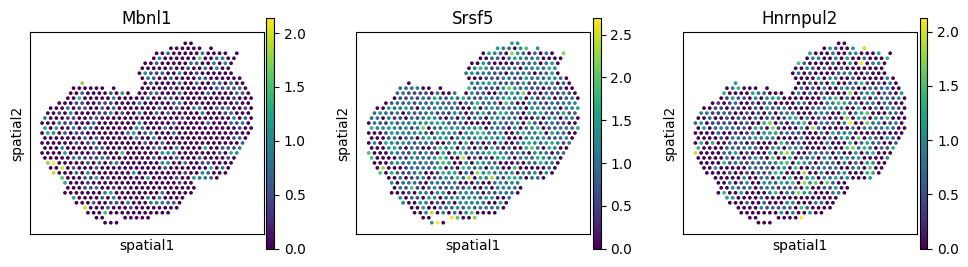

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/1108538305.py:12: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


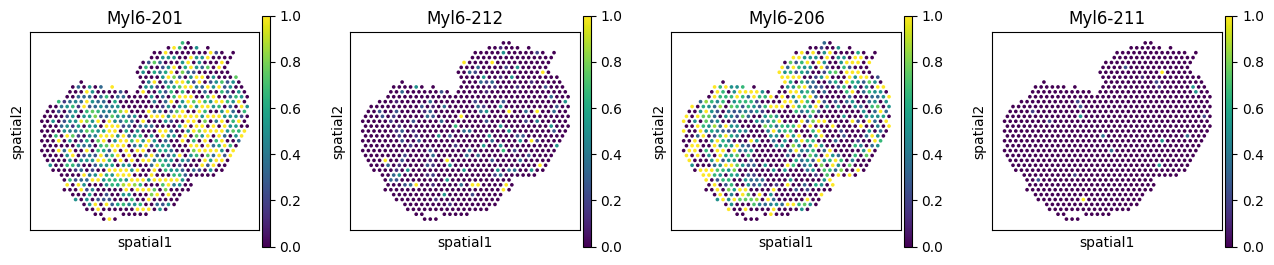

In [25]:
_rbps = ['Mbnl1', 'Srsf5', 'Hnrnpul2']
_gene = 'Myl6'
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.spatial(
        adata_rbp, color=_rbps, title=_rbps,
        img_key=None, layer='log1p', ncols = len(_rbps)
    )

_iso_to_plot = adata_ont.var.index[adata_ont.var['gene_symbol'] == _gene]
_name_to_plot = adata_ont.var.loc[adata_ont.var['gene_symbol'] == _gene, 'transcript_name']
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.spatial(
        adata_ont, color=_iso_to_plot, title=_name_to_plot,
        img_key=None, layer='ratios_obs', ncols = len(_iso_to_plot)
    )

### (Optional) Differential usage tests with `SplisosmGLMM`

Conventionally, differential splicing analysis is often performed using parametric models such as generalized linear models (GLM), which are implemented in `SplisosmGLMM`. We can run the same DU tests using `SplisosmGLMM` and compare the results with the non-parametric HSIC-based tests (results will be different).

#### GLM-based differential usage test (analogous to `SplisosmNP` with the unconditional `method='hsic'`)

Let's first run the unconditional `SplisosmNP` HSIC test as baseline.

In [26]:
%%time
# Model setup
model_hsic = SplisosmNP()
model_hsic.setup_data(
    adata=adata_svp,
    design_mtx=design_mtx,
    covariate_names=covariate_names,
    spatial_key="spatial",
    layer="counts",
    group_iso_by="gene_symbol",
    gene_names="gene_symbol",
    min_counts=10,
    min_bin_pct=0.01,
    skip_spatial_kernel=True, # DU test does not require initializing spatial kernel
)

# Unconditional HSIC test
model_hsic.test_differential_usage(method="hsic")
du_hsic_res = model_hsic.get_formatted_test_results(
    test_type="du"
).rename(columns={"pvalue": "pvalue_hsic"})


DU [hsic]:   0%|          | 0/51 [00:00<?, ?it/s]

DU [hsic]:  39%|███▉      | 20/51 [00:03<00:05,  6.15it/s]

DU [hsic]:  59%|█████▉    | 30/51 [00:06<00:04,  4.41it/s]

DU [hsic]:  78%|███████▊  | 40/51 [00:09<00:02,  3.82it/s]

DU [hsic]:  98%|█████████▊| 50/51 [00:12<00:00,  3.51it/s]

DU [hsic]: 100%|██████████| 51/51 [00:12<00:00,  3.95it/s]

CPU times: user 11.2 s, sys: 33.9 s, total: 45.1 s
Wall time: 16.7 s


Next, set up a Multinomial GLM model and run the score test for association.

In [27]:
%%time
# Model setup for GLM-based DU test
model_glm = SplisosmGLMM(
    model_type="glm", # the unconditional DU test
)
model_glm.setup_data(
    adata=adata_svp,
    design_mtx=design_mtx,
    covariate_names=covariate_names,
    spatial_key="spatial",
    layer="counts",
    group_iso_by="gene_symbol",
    gene_names="gene_symbol",
    min_counts=10,
    min_bin_pct=0.01,
)

# Model fitting
model_glm.fit(with_design_mtx=False)

# DU test with the score statistic
model_glm.test_differential_usage(method="score")
du_glm = model_glm.get_formatted_test_results(test_type="du").sort_values("pvalue")
du_glm.rename(columns={"pvalue": "pvalue_glm"}, inplace=True)

Fitting with single core for 51 genes (batch_size=1).


Fitting:   0%|          | 0/51 [00:00<?, ?it/s]

Fitting:  55%|█████▍    | 28/51 [00:00<00:00, 274.88it/s]

Fitting: 100%|██████████| 51/51 [00:00<00:00, 309.89it/s]

Fitting finished. Time elapsed: 0.17 seconds.


...

DU [score]:  55%|█████▍    | 28/51 [00:00<00:00, 66.43it/s]

DU [score]:  71%|███████   | 36/51 [00:00<00:00, 69.98it/s]

DU [score]:  86%|████████▋ | 44/51 [00:00<00:00, 71.42it/s]

DU [score]: 100%|██████████| 51/51 [00:00<00:00, 70.32it/s]

CPU times: user 925 ms, sys: 104 ms, total: 1.03 s
Wall time: 922 ms


#### GLMM-based differential usage test (analogous to `SplisosmNP` with the conditional `method='hsic-gp'`)

In [28]:
%%time
# Model setup for GLMM-based DU test
model_glmm = SplisosmGLMM(
    model_type="glmm-full",
    fitting_method="joint_gd",
    var_fix_sigma=True,
    fitting_configs={"max_epochs": -1}, # until convergence
    device="cpu", # optional GPU support
    approx_rank=None # optional low-rank kernel approximation
)
model_glmm.setup_data(
    adata=adata_svp,
    design_mtx=design_mtx,
    covariate_names=covariate_names,
    spatial_key="spatial",
    layer="counts",
    group_iso_by="gene_symbol",
    gene_names="gene_symbol",
    min_counts=10,
    min_bin_pct=0.01,
    group_gene_by_n_iso=False, # optional batching
)

# Model fitting
model_glmm.fit(
    n_jobs=1, # optional joblib parallelization
    batch_size=1, # optional batching
    with_design_mtx=False,
    quiet=True, # suppress non-convergence warnings
)

# DU test with the score statistic
model_glmm.test_differential_usage(method="score")
du_glmm = model_glmm.get_formatted_test_results(test_type="du").sort_values("pvalue")
du_glmm.rename(columns={"pvalue": "pvalue_glmm"}, inplace=True)

Fitting with single core for 51 genes (batch_size=1).


Fitting:   0%|          | 0/51 [00:00<?, ?it/s]

Fitting:   2%|▏         | 1/51 [00:05<04:23,  5.27s/it]

Fitting:   4%|▍         | 2/51 [00:08<03:20,  4.09s/it]

Fitting:   6%|▌         | 3/51 [00:11<02:47,  3.48s/it]

...

DU [score]:  69%|██████▊   | 35/51 [00:00<00:00, 63.93it/s]

DU [score]:  82%|████████▏ | 42/51 [00:00<00:00, 65.61it/s]

DU [score]:  98%|█████████▊| 50/51 [00:00<00:00, 68.36it/s]

DU [score]: 100%|██████████| 51/51 [00:00<00:00, 65.48it/s]

CPU times: user 3min 2s, sys: 18.7 s, total: 3min 20s
Wall time: 2min 59s


Let's check model fitting summary and see how long it takes for the per-gene GLMMs to converge.

In [29]:
model_glmm.get_training_summary().head(5)

,model_type,converged,best_loss,best_epoch,fitting_time_s
gene,,,,,
Ift20,glmm-full,True,597.396851,6820,4.766934
Zmat2,glmm-full,True,-96.564835,5447,3.272430
Nt5c3,glmm-full,True,-221.691910,4606,2.750736
Btbd6,glmm-full,True,-4024.287354,2722,2.037541
Comt,glmm-full,True,-342.045227,4685,2.878839


We can visualize the inferred posterior isoform ratios from the GLMM model. Due to data sparsity, the model almost always underestimates the random effect variance (sigma^2), and the resulting ratios look over-smoothed. Setting `var_fix_sigma=True` (our default) helps mitigate this issue.

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/3009630499.py:10: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


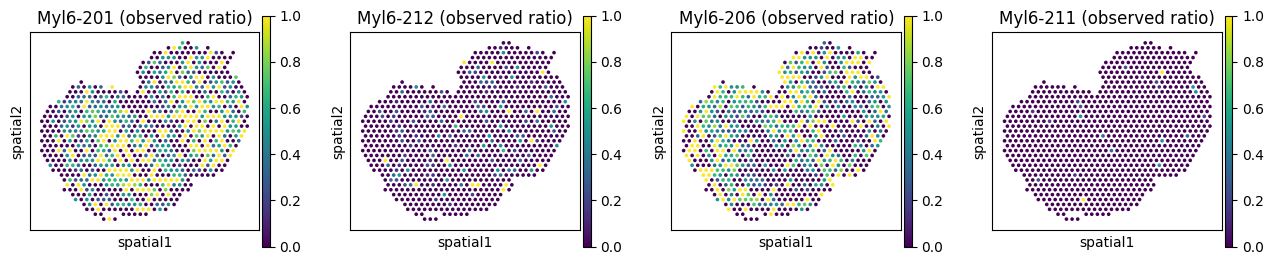

/var/folders/_f/m4v2g8c54gdfks59bp2f2cm80000gn/T/ipykernel_85117/3009630499.py:14: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


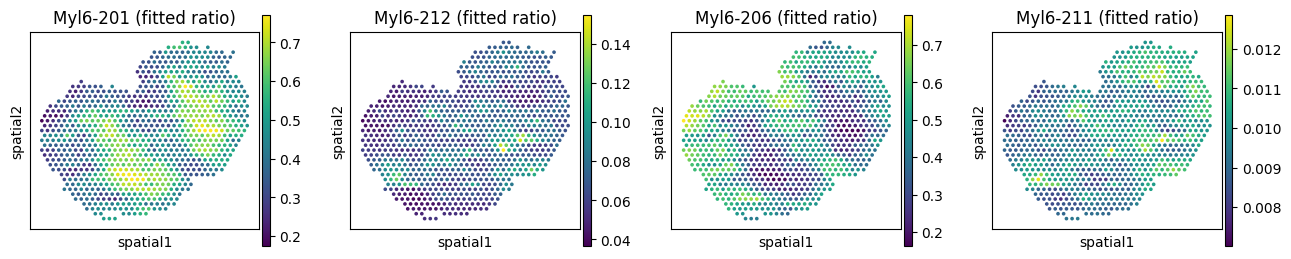

In [30]:
# Extract anndata with fitted ratios for visualization
adata_fit = model_glmm.get_fitted_ratios_anndata(layer_name="ratios_glmm")

# Observed vs fitted ratios for Myl6
_iso_to_plot = adata_fit.var.index[adata_fit.var['gene_symbol'] == _gene]
_name_to_plot = adata_fit.var.loc[adata_fit.var['gene_symbol'] == _gene, 'transcript_name']
_titles_obs = [f"{name} (observed ratio)" for name in _name_to_plot]
_titles_glmm = [f"{name} (fitted ratio)" for name in _name_to_plot]
with plt.rc_context({"figure.figsize": (3, 3)}):
    sc.pl.spatial(
        adata_fit, color=_iso_to_plot, title=_titles_obs,
        img_key=None, layer='ratios_obs', ncols = len(_iso_to_plot)
    )
    sc.pl.spatial(
        adata_fit, color=_iso_to_plot, title=_titles_glmm,
        img_key=None, layer='ratios_glmm', ncols = len(_iso_to_plot)
    )

#### Compare GLM/GLMM results with HSIC-based results

In [31]:
def _neg_log10(p, floor=1e-300):
    return -np.log10(np.clip(p, floor, 1.0))

merge_cols = ["gene", "covariate"]

du_all = (
    du_rbp_sklearn[merge_cols + ["pvalue_np"]]
    .merge(du_hsic_res[merge_cols + ["pvalue_hsic"]], on=merge_cols, how="inner")
    .merge(du_glm[merge_cols + ["pvalue_glm"]], on=merge_cols, how="inner")
    .merge(du_glmm[merge_cols + ["pvalue_glmm"]], on=merge_cols, how="inner")
)

# Spearman correlations between DU methods
rho_hsic, _ = spearmanr(du_all["pvalue_hsic"],    du_all["pvalue_np"])
rho_glmm, _  = spearmanr(du_all["pvalue_glm"],    du_all["pvalue_glmm"])
rho_np_glm, _  = spearmanr(du_all["pvalue_hsic"],    du_all["pvalue_glm"])
rho_np_glmm, _  = spearmanr(du_all["pvalue_np"],    du_all["pvalue_glmm"])

print(f"Spearman ρ(HSIC vs HSIC-GP) = {rho_hsic:.3f}")
print(f"Spearman ρ(GLM vs GLMM) = {rho_glmm:.3f}")
print(f"Spearman ρ(HSIC vs GLM) = {rho_np_glm:.3f}")
print(f"Spearman ρ(HSIC-GP vs GLMM) = {rho_np_glmm:.3f}")

Spearman ρ(HSIC vs HSIC-GP) = 0.868
Spearman ρ(GLM vs GLMM) = 0.921
Spearman ρ(HSIC vs GLM) = 0.709
Spearman ρ(HSIC-GP vs GLMM) = 0.626


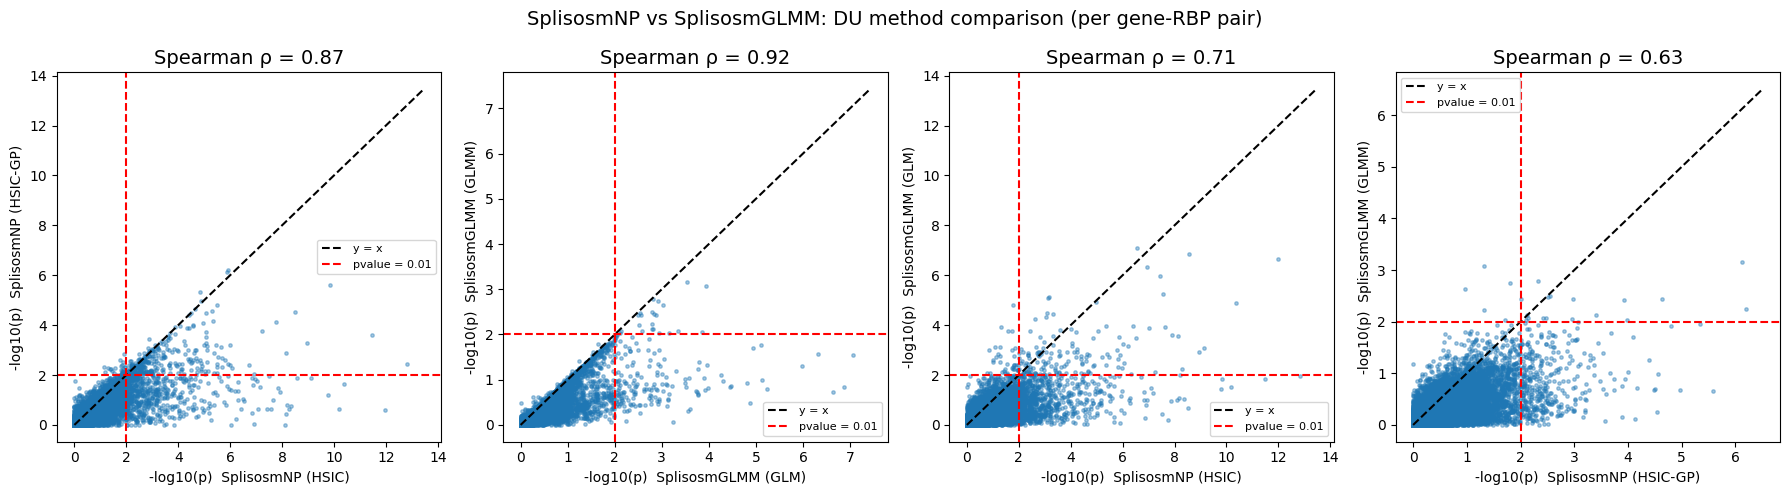

In [32]:
pairs_du = [
    ("pvalue_hsic",   "pvalue_np",
     "SplisosmNP (HSIC)", "SplisosmNP (HSIC-GP)",  rho_hsic),
    ("pvalue_glm",   "pvalue_glmm",
     "SplisosmGLMM (GLM)", "SplisosmGLMM (GLMM)",  rho_glmm),
    ("pvalue_hsic",    "pvalue_glm",
     "SplisosmNP (HSIC)", "SplisosmGLMM (GLM)",  rho_np_glm),
    ("pvalue_np",    "pvalue_glmm",
     "SplisosmNP (HSIC-GP)", "SplisosmGLMM (GLMM)",  rho_np_glmm),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, (cx, cy, lx, ly, rho) in zip(axes, pairs_du):
    x = _neg_log10(du_all[cx].astype(float).values, floor=1e-100)
    y = _neg_log10(du_all[cy].astype(float).values, floor=1e-100)
    ax.scatter(x, y, s=6, alpha=0.4, rasterized=True)
    lim = max(x.max(), y.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", label="y = x")
    ax.axhline(_neg_log10(0.01), color="red", linestyle="--", label="pvalue = 0.01")
    ax.axvline(_neg_log10(0.01), color="red", linestyle="--")
    ax.set_xlabel(f"-log10(p)  {lx}", fontsize=10)
    ax.set_ylabel(f"-log10(p)  {ly}", fontsize=10)
    ax.set_title(f"Spearman ρ = {rho:.2f}", fontsize=14)
    ax.legend(fontsize=8)

fig.suptitle("SplisosmNP vs SplisosmGLMM: DU method comparison (per gene-RBP pair)", fontsize=14)
fig.tight_layout()
plt.show()

## For reproducibility

In [33]:
import sys
from datetime import date
import splisosm

print("Last updated:", date.today())
print("Python:", sys.version.split()[0])
print("splisosm:", getattr(splisosm, "__version__", "unknown"))

Last updated: 2026-04-26
Python: 3.12.13
splisosm: 1.2.0rc1
